## Simple Linear Regression

In [22]:
!pip install matplotlib
!pip install numpy


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
x1 = [
    0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 
    5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0,
    11.0, 12.0, 13.0, 14.0, 15.0
]
y = [
    41, 44, 42, 51, 48, 55, 60, 58, 64, 69, 
    71, 70, 78, 81, 84, 80, 88, 92, 90, 95,
    96, 98, 99, 97, 100
]

In [24]:
totallen = len(x1)
trainlen = (totallen/10)*8
print(totallen,trainlen)

25 20.0


In [25]:
import random

indices = list(range(len(x1)))
random.shuffle(indices)

train_x = []
train_y = []
test_x = []
test_y = []

for i in range(0, int(trainlen)):
    idx = indices[i]
    train_x.append(x1[idx])
    train_y.append(y[idx])

for i in range(int(trainlen), len(x1)):
    idx = indices[i]
    test_x.append(x1[idx])
    test_y.append(y[idx])

print(train_x)
print(train_y)
print(test_x)
print(test_y)

[8.0, 4.0, 8.5, 9.5, 3.5, 1.5, 6.0, 4.5, 12.0, 0.5, 13.0, 10.0, 6.5, 3.0, 7.5, 9.0, 1.0, 5.5, 5.0, 2.5]
[80, 58, 88, 90, 60, 42, 70, 64, 98, 41, 99, 95, 78, 55, 84, 92, 44, 71, 69, 48]
[15.0, 2.0, 7.0, 11.0, 14.0]
[100, 51, 81, 96, 97]


In [26]:
def findslope(x,y):
    xmean = sum(x)/len(x)
    ymean = sum(y)/len(y)
    print(xmean)
    print(ymean)
    num = 0.0
    den = 0.0
    for i in range (0,len(x)):
        num = num + ((x[i]-xmean)*(y[i]-ymean))
        den = den + (x[i]-xmean)**2
    return num/den

m1 = findslope(train_x,train_y)
print(m1)

6.05
71.3
5.2625789366469755


In [27]:
x1mean = sum(train_x)/len(train_x)
ymean = sum(train_y)/len(train_y)

c = ymean - (m1*x1mean)

In [28]:
def func(x):
    y = []
    for i in range (0,len(x)):
        y.append((m1*x[i])+c)
    return y
y_train_pred = func(train_x)
y_test_pred = func(test_x)
print(y_train_pred)
print(y_test_pred)

[81.56202892646161, 60.511713179873695, 84.19331839478508, 89.45589733143206, 57.88042371155021, 47.35526583825626, 71.03687105316766, 63.14300264819718, 102.6123446730495, 42.092686901609284, 107.87492360969648, 92.08718679975556, 73.66816052149113, 55.24913424322672, 78.9307394581381, 86.82460786310858, 44.72397636993277, 68.40558158484416, 65.77429211652067, 52.61784477490323]
[118.40008148299043, 49.986555306579746, 76.29944998981463, 97.34976573640253, 113.13750254634346]


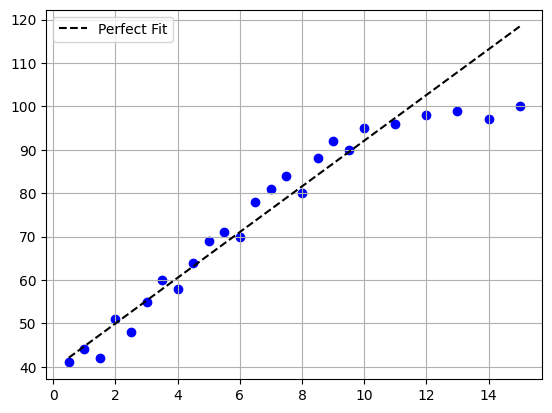

In [29]:
import matplotlib.pyplot as plt
plt.scatter(x1,y,color="blue")
plt.plot(x1,func(x1), color='black', linestyle='--', label='Perfect Fit')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
import numpy as np

# convert lists to numpy arrays (no change to your logic)
train_y_arr = np.array(train_y)
test_y_arr = np.array(test_y)

y_train_pred_arr = np.array(y_train_pred)
y_test_pred_arr = np.array(y_test_pred)

# function for metrics
def evaluate(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)

    return r2, mae, mse, rmse


# TRAIN metrics
train_r2, train_mae, train_mse, train_rmse = evaluate(train_y_arr, y_train_pred_arr)

# TEST metrics
test_r2, test_mae, test_mse, test_rmse = evaluate(test_y_arr, y_test_pred_arr)


print("\nTRAIN METRICS")
print("R2:", train_r2)
print("MAE:", train_mae)
print("MSE:", train_mse)
print("RMSE:", train_rmse)

print("\nTEST METRICS")
print("R2:", test_r2)
print("MAE:", test_mae)
print("MSE:", test_mse)
print("RMSE:", test_rmse)


TRAIN METRICS
R2: 0.9606389322612274
MAE: 3.063678957017724
MSE: 13.926339376655136
RMSE: 3.731801090178191

TEST METRICS
R2: 0.6245932039097651
MAE: 8.320268893868407
MSE: 124.78521902039407
RMSE: 11.170730460466498


## Multiple Linear Regression

In [31]:
import numpy as np
x = np.array([[4,1,3],[9,2,1],[8,3,2],[8,1,1],[7,1,4],[5,0,2]])
y = np.array([52,51,50,52,70,60])
z = np.array([1,1,1])
x = np.c_[np.ones((x.shape[0], 1)), x]
print(x)
print(y)

[[1. 4. 1. 3.]
 [1. 9. 2. 1.]
 [1. 8. 3. 2.]
 [1. 8. 1. 1.]
 [1. 7. 1. 4.]
 [1. 5. 0. 2.]]
[52 51 50 52 70 60]


In [32]:
x_ = x.T.dot(x)
x_inv = np.linalg.inv(x_)
beta = x_inv.dot(x.T.dot(y))
print(beta)

[28.70422535  3.12676056 -6.          6.35211268]


In [33]:
test = np.array([1,6,1,1])
pred = test.dot(beta)
print(pred)

47.81690140845086


In [34]:
intercept = beta[0]
coefficients = beta[1:]

print("Intercept:", intercept)
print("Coefficients:", coefficients)

Intercept: 28.704225352112644
Coefficients: [ 3.12676056 -6.          6.35211268]


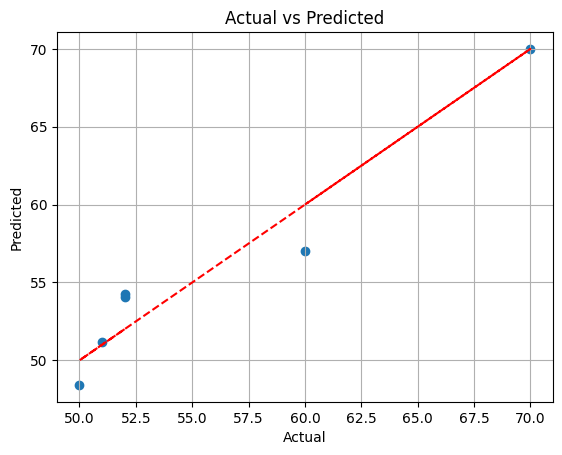

In [35]:
plt.scatter(y, y_pred)

# Add perfect prediction line
plt.plot(y, y, color='red', linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

In [36]:
y_pred = x.dot(beta)

# mean of y
y_mean = np.mean(y)

# R² calculation
ss_res = np.sum((y - y_pred)**2)   # residual error
ss_tot = np.sum((y - y_mean)**2)   # total variance

r2 = 1 - (ss_res / ss_tot)

print("R² Score:", r2)

R² Score: 0.9320801792713636


In [37]:
mae = np.mean(np.abs(y - y_pred))
print("MAE:", mae)

MAE: 1.5117370892019533


In [38]:
mse = np.mean((y - y_pred)**2)
print("MSE:", mse)

MSE: 3.4507042253521125


In [39]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 1.8576071235199634
